In [1]:
import pandas as pd
import numpy as np
from pydantic import BaseModel, field_validator
import pathlib
import collections
from typing import Literal, Optional, List
from datetime import datetime, timedelta, date

In [2]:
files = list(pathlib.Path('../data/gold').resolve().rglob('*.parquet'))
def get_type(name):
    return '_'.join(name.split('/')[-1].split('_')[:-1])

In [3]:
collections.Counter([get_type(x.name) for x in files])

Counter({'telemetry_pos': 30,
         'telemetry_car': 30,
         'session_laptimings': 2,
         'session_laps': 2,
         'circuit_markers': 2,
         'session_weather': 2,
         'session_race_control_messages': 2,
         'session_results': 2,
         'session_track_status': 2,
         'session_metadata': 2,
         'historical': 1})

In [4]:
df1 = pd.read_parquet([x for x in files if get_type(x.name)=='historical'][0])

In [5]:
df1.head().T

,0,1,2,3,4
year,1950,1950,1950,1950,1950
round_number,1,1,1,1,1
event_name,British Grand Prix,British Grand Prix,British Grand Prix,British Grand Prix,British Grand Prix
event_format,conventional,conventional,conventional,conventional,conventional
event_date,1950-05-13,1950-05-13,1950-05-13,1950-05-13,1950-05-13
country,UK,UK,UK,UK,UK
location,Silverstone,Silverstone,Silverstone,Silverstone,Silverstone
official_event_name,None,None,None,None,None
has_api_support,False,False,False,False,False
session_number,1,2,3,4,5


In [6]:
df1.nunique()

year                     77
round_number             25
event_name               60
event_format              5
event_date             1181
country                  39
location                 84
official_event_name     204
has_api_support           2
session_number            5
session_name              8
session_time_utc       3927
dtype: int64

In [7]:
df1['event_format'].value_counts()

event_format
conventional         5703
sprint_qualifying      90
testing                30
sprint                 30
sprint_shootout        30
Name: count, dtype: int64

In [8]:
df1['session_name'].value_counts()

session_name
Practice 1           1181
Qualifying           1171
Race                 1171
Practice 2           1156
Practice 3           1150
Sprint                 30
Sprint Qualifying      18
Sprint Shootout         6
Name: count, dtype: int64

In [9]:
df1.isna().sum()

year                      0
round_number              0
event_name                0
event_format              0
event_date                0
country                   0
location                  0
official_event_name    4880
has_api_support           0
session_number            0
session_name              0
session_time_utc          0
dtype: int64

In [10]:
class HistoricalSessions(BaseModel):
    year: int
    round_number: int
    event_name: str
    event_format: Literal["conventional", "testing", "sprint", "sprint_shootout", "sprint_qualifying"]
    event_date: date
    country: str
    location: str
    official_event_name: Optional[str]
    has_api_support: bool
    session_number: Literal[1, 2, 3, 4, 5]
    session_name: Literal["Practice 1", "Practice 2", "Practice 3", "Qualifying", "Race", "Sprint", "Sprint Qualifying", "Sprint Shootout"]
    session_time_utc: datetime


In [11]:
data1 = [HistoricalSessions(**x) for _, x in df1.iterrows()]

In [12]:
data1[-5:]

[HistoricalSessions(year=2026, round_number=22, event_name='Abu Dhabi Grand Prix', event_format='conventional', event_date=datetime.date(2026, 12, 6), country='United Arab Emirates', location='Yas Marina', official_event_name='FORMULA 1 ETIHAD AIRWAYS ABU DHABI GRAND PRIX 2026', has_api_support=True, session_number=1, session_name='Practice 1', session_time_utc=Timestamp('2026-12-04 09:30:00')),
 HistoricalSessions(year=2026, round_number=22, event_name='Abu Dhabi Grand Prix', event_format='conventional', event_date=datetime.date(2026, 12, 6), country='United Arab Emirates', location='Yas Marina', official_event_name='FORMULA 1 ETIHAD AIRWAYS ABU DHABI GRAND PRIX 2026', has_api_support=True, session_number=2, session_name='Practice 2', session_time_utc=Timestamp('2026-12-04 13:00:00')),
 HistoricalSessions(year=2026, round_number=22, event_name='Abu Dhabi Grand Prix', event_format='conventional', event_date=datetime.date(2026, 12, 6), country='United Arab Emirates', location='Yas Marin

In [13]:
df2 = pd.read_parquet([x for x in files if get_type(x.name)=='session_metadata'][0])

In [14]:
df2.head().T

,0,1,2,3,4
year,2026,2026,2026,2026,2026
session_id,Y2026R01S1,Y2026R01S2,Y2026R01S3,Y2026R01S4,Y2026R01S5
session_name,Practice 1,Practice 2,Practice 3,Qualifying,Race
f1_api_support,True,True,True,True,True
timestamp_reference,2026-03-06 01:15:00.012000+00:00,2026-03-06 04:47:12.180000+00:00,2026-03-07 01:24:00.062000+00:00,2026-03-07 04:47:18.712000+00:00,2026-03-08 03:01:06.623000+00:00
timing_start,900.171,767.995,1560.124,761.484,3739.743
session_scheduled_time,2026-03-06 01:30:00+00:00,2026-03-06 05:00:00+00:00,2026-03-07 01:30:00+00:00,2026-03-07 05:00:00+00:00,2026-03-08 04:00:00+00:00
total_laps,NaN,NaN,NaN,NaN,58.0
driver_list,"[1, 3, 5, 6, 10, 11, 12, 14, 16, 18, 23, 27, 3...","[1, 3, 5, 6, 10, 11, 12, 14, 16, 18, 23, 27, 3...","[1, 3, 5, 6, 10, 11, 12, 14, 16, 18, 23, 27, 3...","[1, 3, 5, 6, 10, 11, 12, 14, 16, 18, 23, 27, 3...","[1, 3, 5, 6, 10, 11, 12, 14, 16, 18, 23, 27, 3..."
meeting_key,1279,1279,1279,1279,1279


In [15]:
class SessionMetadata(BaseModel):
    year: int
    session_id: str
    session_name: Literal["Practice 1", "Practice 2", "Practice 3", "Qualifying", "Race", "Sprint", "Sprint Qualifying", "Sprint Shootout"]
    f1_api_support: bool
    timestamp_reference: datetime
    session_scheduled_time: datetime
    timing_start: float
    total_laps: Optional[int]
    driver_list: List[int]
    meeting_key: int
    meeting_name: str
    meeting_official_name: str
    meeting_location: str
    meeting_number: int
    country_key: int
    country_code: str
    country_name: str
    circuit_key: int
    circuit_short_name: str
    round_number: int
    event_country: str
    event_location: str
    event_name: str
    event_official_name: str
    event_date: date 
    event_format: Literal["conventional", "testing", "sprint", "sprint_shootout", "sprint_qualifying"]
    type: Literal["Practice 1", "Practice 2", "Practice 3", "Qualifying", "Race", "Sprint", "Sprint Qualifying", "Sprint Shootout"]
    scheduled_time_utc: datetime
    scheduled_time_local: datetime

    @field_validator('total_laps', mode='before')
    @staticmethod
    def total_laps(value):
        try:
            return int(value)
        except (TypeError, ValueError):
            return None

    

In [59]:
df2['type'].value_counts()

type
Practice 1           5
Practice 2           4
Practice 3           4
Qualifying           3
Race                 3
Sprint Qualifying    1
Sprint               1
Name: count, dtype: int64

In [17]:
data2 = [SessionMetadata(**x) for _, x in df2.iterrows()]

In [18]:
sorted(data2, key=lambda x: x.session_scheduled_time)[-5:]

[SessionMetadata(year=2026, session_id='Y2026R03S1', session_name='Practice 1', f1_api_support=True, timestamp_reference=Timestamp('2026-03-27 02:15:24.385000+0000', tz='UTC'), session_scheduled_time=Timestamp('2026-03-27 02:30:00+0000', tz='UTC'), timing_start=875.77, total_laps=None, driver_list=[1, 3, 5, 6, 10, 11, 12, 16, 18, 23, 27, 30, 31, 34, 41, 43, 44, 55, 63, 77, 81, 87], meeting_key=1281, meeting_name='Japanese Grand Prix', meeting_official_name='FORMULA 1 ARAMCO JAPANESE GRAND PRIX 2026', meeting_location='Suzuka', meeting_number=3, country_key=4, country_code='JPN', country_name='Japan', circuit_key=46, circuit_short_name='Suzuka', round_number=3, event_country='Japan', event_location='Suzuka', event_name='Japanese Grand Prix', event_official_name='FORMULA 1 ARAMCO JAPANESE GRAND PRIX 2026', event_date=datetime.date(2026, 3, 29), event_format='conventional', type='Practice 1', scheduled_time_utc=Timestamp('2026-03-27 02:30:00+0000', tz='UTC'), scheduled_time_local=datetime

In [19]:
data2[10].scheduled_time_utc.strftime('%H:%M:%S%z')

'02:30:00+0000'

In [20]:
data2[10].scheduled_time_local.strftime('%H:%M:%S%z')

'11:30:00+0900'

In [21]:
collections.Counter([x.total_laps for x in data2])

Counter({None: 17, 58: 1, 19: 1, 56: 1, 53: 1})

In [22]:
df3 = pd.read_parquet([x for x in files if get_type(x.name)=='session_results'][0])

In [23]:
df3.head().T

,0,1,2,3,4
year,2025,2025,2025,2025,2025
session_id,Y2025R01S1,Y2025R01S1,Y2025R01S1,Y2025R01S1,Y2025R01S1
driver_id,max_verstappen,gasly,antonelli,alonso,leclerc
driver_number,1,10,12,14,16
driver_broadcast_name,M VERSTAPPEN,P GASLY,A ANTONELLI,F ALONSO,C LECLERC
driver_abbreviation,VER,GAS,ANT,ALO,LEC
driver_first_name,Max,Pierre,Andrea Kimi,Fernando,Charles
driver_last_name,Verstappen,Gasly,Antonelli,Alonso,Leclerc
driver_full_name,Max Verstappen,Pierre Gasly,Andrea Kimi Antonelli,Fernando Alonso,Charles Leclerc
driver_headshot_url,https://media.formula1.com/d_driver_fallback_i...,https://media.formula1.com/d_driver_fallback_i...,https://media.formula1.com/d_driver_fallback_i...,https://media.formula1.com/d_driver_fallback_i...,https://media.formula1.com/d_driver_fallback_i...


In [24]:
df3.isna().sum()

year                        0
session_id                  0
driver_id                 214
driver_number               0
driver_broadcast_name       0
driver_abbreviation         0
driver_first_name           0
driver_last_name            0
driver_full_name            0
driver_headshot_url       124
driver_country_code      2454
team_id                   214
team_name                   0
team_color                  0
position                 1256
classified_position      1921
grid_position            1855
time_q1                  1863
time_q2                  2015
time_q3                  2158
time                     1927
status                   1855
points                   1855
dtype: int64

In [25]:
df3[df3['driver_id'].isna()]

,year,session_id,driver_id,driver_number,driver_broadcast_name,driver_abbreviation,driver_first_name,driver_last_name,driver_full_name,driver_headshot_url,...,team_color,position,classified_position,grid_position,time_q1,time_q2,time_q3,time,status,points
120,2025,Y2025R02S2,None,1,M VERSTAPPEN,VER,Max,Verstappen,Max Verstappen,https://media.formula1.com/d_driver_fallback_i...,...,3671C6,2,<NA>,<NA>,91.916,91.521,90.867,NaN,None,NaN
121,2025,Y2025R02S2,None,10,P GASLY,GAS,Pierre,Gasly,Pierre Gasly,https://media.formula1.com/d_driver_fallback_i...,...,0093CC,17,<NA>,<NA>,92.640,NaN,NaN,NaN,None,NaN
122,2025,Y2025R02S2,None,12,A ANTONELLI,ANT,Andrea Kimi,Antonelli,Andrea Kimi Antonelli,https://media.formula1.com/d_driver_fallback_i...,...,27F4D2,7,<NA>,<NA>,91.999,91.475,91.738,NaN,None,NaN
123,2025,Y2025R02S2,None,14,F ALONSO,ALO,Fernando,Alonso,Fernando Alonso,https://media.formula1.com/d_driver_fallback_i...,...,229971,11,<NA>,<NA>,92.121,91.815,NaN,NaN,None,NaN
124,2025,Y2025R02S2,None,16,C LECLERC,LEC,Charles,Leclerc,Charles Leclerc,https://media.formula1.com/d_driver_fallback_i...,...,E80020,4,<NA>,<NA>,91.518,91.561,91.057,NaN,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2449,2025,Y2025T01S3,None,6,I HADJAR,HAD,Isack,Hadjar,Isack Hadjar,https://media.formula1.com/d_driver_fallback_i...,...,6692FF,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,None,NaN
2450,2025,Y2025T01S3,None,63,G RUSSELL,RUS,George,Russell,George Russell,https://media.formula1.com/d_driver_fallback_i...,...,27F4D2,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,None,NaN
2451,2025,Y2025T01S3,None,7,J DOOHAN,DOO,Jack,Doohan,Jack Doohan,https://media.formula1.com/d_driver_fallback_i...,...,0093CC,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,None,NaN
2452,2025,Y2025T01S3,None,81,O PIASTRI,PIA,Oscar,Piastri,Oscar Piastri,https://media.formula1.com/d_driver_fallback_i...,...,FF8000,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,None,NaN


In [26]:
class SessionResults(BaseModel):
    year: int
    session_id: str
    driver_id: Optional[str]
    driver_number: int
    driver_broadcast_name: str
    driver_abbreviation: str
    driver_first_name: str
    driver_last_name: str
    driver_full_name: str
    driver_headshot_url: Optional[str]
    team_color: str
    position: Optional[int]
    classified_position: Optional[int]
    grid_position: Optional[int]
    time_q1: Optional[float]
    time_q2: Optional[float]
    time_q3: Optional[float]
    time: Optional[float]
    status: Literal[None, 'Finished', 'Retired', 'Disqualified', 'Lapped', 'Did not start']
    points: Optional[int]

    @staticmethod
    def parse_int(value):
        try:
            return int(value)
        except (TypeError, ValueError):
            return None

    @staticmethod
    def parse_float(value):
        try:
            if np.isnan(value):
                return None
            if value:
                return float(value)            
        except (TypeError, ValueError):
            return None

    @field_validator('position', mode='before')
    @staticmethod
    def position(value):
        return SessionResults.parse_int(value)

    @field_validator('classified_position', mode='before')
    @staticmethod
    def classified_position(value):
        return SessionResults.parse_int(value)

    @field_validator('grid_position', mode='before')
    @staticmethod
    def grid_position(value):
        return SessionResults.parse_int(value)

    @field_validator('points', mode='before')
    @staticmethod
    def points(value):
        return SessionResults.parse_int(value)

    @field_validator('time_q1', mode='before')
    @staticmethod
    def time_q1(value):
        return SessionResults.parse_float(value)

    @field_validator('time_q2', mode='before')
    @staticmethod
    def time_q2(value):
        return SessionResults.parse_float(value)

    @field_validator('time_q3', mode='before')
    @staticmethod
    def time_q3(value):
        return SessionResults.parse_float(value)

    @field_validator('time', mode='before')
    @staticmethod
    def time(value):
        return SessionResults.parse_float(value)


In [27]:
df3['status'].unique()

array([None, 'Finished', 'Retired', 'Disqualified', 'Lapped',
       'Did not start'], dtype=object)

In [28]:
data3 = [SessionResults(**x) for _, x in df3.iterrows()]

In [29]:
[x for x in data3 if x.time is not None][-10:]

[SessionResults(year=2025, session_id='Y2025R24S5', driver_id='ocon', driver_number=31, driver_broadcast_name='E OCON', driver_abbreviation='OCO', driver_first_name='Esteban', driver_last_name='Ocon', driver_full_name='Esteban Ocon', driver_headshot_url='https://media.formula1.com/d_driver_fallback_image.png/content/dam/fom-website/drivers/E/ESTOCO01_Esteban_Ocon/estoco01.png.transform/1col/image.png', team_color='9C9FA2', position=7, classified_position=7, grid_position=8, time_q1=None, time_q2=None, time_q3=None, time=69.876, status='Finished', points=6),
 SessionResults(year=2025, session_id='Y2025R24S5', driver_id='norris', driver_number=4, driver_broadcast_name='L NORRIS', driver_abbreviation='NOR', driver_first_name='Lando', driver_last_name='Norris', driver_full_name='Lando Norris', driver_headshot_url='https://media.formula1.com/d_driver_fallback_image.png/content/dam/fom-website/drivers/L/LANNOR01_Lando_Norris/lannor01.png.transform/1col/image.png', team_color='F47600', positi

In [30]:
df4 = pd.read_parquet([x for x in files if get_type(x.name)=='session_laps'][0])
df4.head().T

,0,1,2,3,4
year,2025,2025,2025,2025,2025
session_id,Y2025R01S1,Y2025R01S1,Y2025R01S1,Y2025R01S1,Y2025R01S1
driver_number,1,1,1,1,1
driver_name,VER,VER,VER,VER,VER
driver_team,Red Bull Racing,Red Bull Racing,Red Bull Racing,Red Bull Racing,Red Bull Racing
lap_number,1,2,3,4,5
stint,1.0,1.0,1.0,1.0,1.0
timestamp_lap_start,2025-03-14 01:30:56.193000+00:00,2025-03-14 01:32:43.011000+00:00,2025-03-14 01:34:02.782000+00:00,2025-03-14 01:36:26.697000+00:00,2025-03-14 01:37:45.846000+00:00
timing_start_lap,928.184,1035.002,1114.773,1258.688,1337.837
timing_end_lap,1035.002,1114.773,1258.688,1337.837,1486.613


In [31]:
class SessionLaps(BaseModel):
    year: int
    session_id: str
    driver_number: int
    driver_name: str
    driver_team: str
    lap_number: int
    stint: Optional[int]
    timestamp_lap_start: datetime
    timing_start_lap: Optional[float]
    timing_end_lap: Optional[float]
    timing_end_sector1: Optional[float]
    timing_end_sector2: Optional[float]
    timing_end_sector3: Optional[float]
    timing_pit_out: Optional[float]
    timing_pit_in: Optional[float]
    time_lap: Optional[float]
    time_sector1: Optional[float]
    time_sector2: Optional[float]
    time_sector3: Optional[float]
    tyre_compound: Literal[None, "SOFT", "MEDIUM", "HARD", "INTERMEDIATE", "WET", "UNKNOWN"]
    tyre_life: Optional[int]
    speed_i1: Optional[float]
    speed_i2: Optional[float]
    speed_fl: Optional[float]
    speed_st: Optional[float]
    is_personal_best: bool
    track_status: Optional[int]
    position: Optional[int]
    deleted_reason: Optional[str]
    is_accurate: bool
    is_fastf1_generated: bool
    

    @staticmethod
    def parse_int(value):
        try:
            return int(value)
        except (TypeError, ValueError):
            return None

    @staticmethod
    def parse_float(value):
        try:
            if np.isnan(value):
                return None
            if value:
                return float(value)            
        except (TypeError, ValueError):
            return None

    @field_validator('stint', mode='before')
    @staticmethod
    def stint(value):
        return SessionLaps.parse_int(value)

    @field_validator('tyre_life', mode='before')
    @staticmethod
    def tyre_life(value):
        return SessionLaps.parse_int(value)

    @field_validator('track_status', mode='before')
    @staticmethod
    def track_status(value):
        return SessionLaps.parse_int(value)

    @field_validator('position', mode='before')
    @staticmethod
    def position(value):
        return SessionLaps.parse_int(value)

    @field_validator('timing_start_lap', mode='before')
    @staticmethod
    def timing_start_lap(value):
        return SessionLaps.parse_float(value)

    @field_validator('timing_end_lap', mode='before')
    @staticmethod
    def timing_end_lap(value):
        return SessionLaps.parse_float(value)

    @field_validator('timing_end_sector1', mode='before')
    @staticmethod
    def timing_end_sector1(value):
        return SessionLaps.parse_float(value)

    @field_validator('timing_end_sector2', mode='before')
    @staticmethod
    def timing_end_sector2(value):
        return SessionLaps.parse_float(value)

    @field_validator('timing_end_sector3', mode='before')
    @staticmethod
    def timing_end_sector3(value):
        return SessionLaps.parse_float(value)

    @field_validator('timing_pit_in', mode='before')
    @staticmethod
    def timing_pit_in(value):
        return SessionLaps.parse_float(value)

    @field_validator('timing_pit_out', mode='before')
    @staticmethod
    def timing_pit_out(value):
        return SessionLaps.parse_float(value)

    @field_validator('time_lap', mode='before')
    @staticmethod
    def time_lap(value):
        return SessionLaps.parse_float(value)

    @field_validator('time_sector1', mode='before')
    @staticmethod
    def time_sector1(value):
        return SessionLaps.parse_float(value)

    @field_validator('time_sector2', mode='before')
    @staticmethod
    def time_sector2(value):
        return SessionLaps.parse_float(value)

    @field_validator('time_sector3', mode='before')
    @staticmethod
    def time_sector3(value):
        return SessionLaps.parse_float(value)

    @field_validator('speed_i1', mode='before')
    @staticmethod
    def speed_i1(value):
        return SessionLaps.parse_float(value)

    @field_validator('speed_i2', mode='before')
    @staticmethod
    def speed_i2(value):
        return SessionLaps.parse_float(value)

    @field_validator('speed_fl', mode='before')
    @staticmethod
    def speed_fl(value):
        return SessionLaps.parse_float(value)

    @field_validator('speed_st', mode='before')
    @staticmethod
    def speed_st(value):
        return SessionLaps.parse_float(value)


In [62]:
df4[['deleted_status', 'deleted_reason']].value_counts(dropna=False)

deleted_status  deleted_reason                 
False           NaN                                69029
True            TRACK LIMITS AT TURN 10 LAP 9          7
                TRACK LIMITS AT TURN 10 LAP 8          6
                TRACK LIMITS AT TURN 10 LAP 6          6
                TRACK LIMITS AT TURN 1 LAP 5           6
                                                   ...  
                TRACK LIMITS AT TURN 14 LAP 4          1
                TRACK LIMITS AT TURN 14 LAP 41         1
                TRACK LIMITS AT TURN 14 LAP 44         1
                TRACK LIMITS AT TURN 14 LAP 53         1
                TRACK LIMITS AT TURN 9 LAP 9           1
Name: count, Length: 323, dtype: int64

In [32]:

data4 = [SessionLaps(**x) for _, x in df4.iterrows()]

In [33]:
collections.Counter([(x.tyre_compound) for x in data4])

Counter({'MEDIUM': 26862,
         'SOFT': 22593,
         'HARD': 17101,
         'INTERMEDIATE': 2062,
         None: 555,
         'WET': 282,
         'UNKNOWN': 39})

In [34]:
[x for x in data4][-50:]

[SessionLaps(year=2025, session_id='Y2025T01S3', driver_number=87, driver_name='BEA', driver_team='Haas F1 Team', lap_number=10, stint=3, timestamp_lap_start=Timestamp('2025-02-28 08:45:24.367000+0000', tz='UTC'), timing_start_lap=7224.172, timing_end_lap=7318.03, timing_end_sector1=7254.092, timing_end_sector2=7294.862, timing_end_sector3=7318.03, timing_pit_out=None, timing_pit_in=None, time_lap=93.858, time_sector1=29.92, time_sector2=40.77, time_sector3=23.168, tyre_compound='MEDIUM', tyre_life=5, speed_i1=237.0, speed_i2=267.0, speed_fl=286.0, speed_st=309.0, is_personal_best=False, track_status=1, position=None, deleted_reason=None, is_accurate=True, is_fastf1_generated=False),
 SessionLaps(year=2025, session_id='Y2025T01S3', driver_number=87, driver_name='BEA', driver_team='Haas F1 Team', lap_number=11, stint=3, timestamp_lap_start=Timestamp('2025-02-28 08:46:58.225000+0000', tz='UTC'), timing_start_lap=7318.03, timing_end_lap=7450.819, timing_end_sector1=7363.799, timing_end_se

In [35]:
df4.isna().sum()

year                       0
session_id                 0
driver_number              0
driver_name                0
driver_team                0
lap_number                 0
stint                    459
timestamp_lap_start       22
timing_start_lap          19
timing_end_lap             0
timing_end_sector1      7112
timing_end_sector2       616
timing_end_sector3      1733
timing_pit_out         59802
timing_pit_in          59927
time_lap               10459
time_sector1            7026
time_sector2             616
time_sector3            1733
tyre_compound            555
tyre_life                590
tyre_fresh                 0
speed_i1                 257
speed_i2                1442
speed_fl                9613
speed_st                 802
is_personal_best           0
track_status              31
position               40691
deleted_status             0
deleted_reason         69029
is_accurate                0
is_fastf1_generated        0
dtype: int64

In [36]:
df5 = pd.read_parquet([x for x in files if get_type(x.name)=='session_laptimings'][0])
df5.head().T
    

,0,1,2,3,4
year,2025,2025,2025,2025,2025
session_id,Y2025R01S1,Y2025R01S1,Y2025R01S1,Y2025R01S1,Y2025R01S1
driver_number,1,1,1,1,1
lap_number,1,2,3,4,5
timestamp_start,2025-03-14 01:30:56.193000+00:00,2025-03-14 01:32:43.011000+00:00,2025-03-14 01:34:02.782000+00:00,2025-03-14 01:36:26.697000+00:00,2025-03-14 01:37:45.846000+00:00
timestamp_pitout,2025-03-14 01:30:56.193000+00:00,NaT,NaT,NaT,NaT
timestamp_sector1,2025-03-14 01:31:35.407000+00:00,2025-03-14 01:33:10.962000+00:00,2025-03-14 01:34:51.986000+00:00,2025-03-14 01:36:54.040000+00:00,2025-03-14 01:38:37.597000+00:00
timestamp_sector2,2025-03-14 01:31:55.176000+00:00,2025-03-14 01:33:28.755000+00:00,2025-03-14 01:35:29.253000+00:00,2025-03-14 01:37:11.495000+00:00,2025-03-14 01:39:20.678000+00:00
timestamp_pitin,NaT,NaT,NaT,NaT,NaT
timestamp_sector3,2025-03-14 01:32:43.133000+00:00,2025-03-14 01:34:02.782000+00:00,2025-03-14 01:36:26.697000+00:00,2025-03-14 01:37:45.846000+00:00,2025-03-14 01:40:14.622000+00:00


In [37]:
class SessionLapTimings(BaseModel):
    year: int
    session_id: str
    driver_number: int
    lap_number: int
    timestamp_start: Optional[datetime]
    timestamp_pitout: Optional[datetime]
    timestamp_sector1: Optional[datetime]
    timestamp_sector2: Optional[datetime]
    timestamp_pitin: Optional[datetime]
    timestamp_sector3: Optional[datetime]
    timestamp_end: Optional[datetime]
    

In [38]:
data5 = [SessionLapTimings(**x) for _, x in df5.iterrows()]

In [39]:
data5[-10:]

[SessionLapTimings(year=2025, session_id='Y2025T01S3', driver_number=87, lap_number=50, timestamp_start=Timestamp('2025-02-28 10:29:07.221000+0000', tz='UTC'), timestamp_pitout=NaT, timestamp_sector1=Timestamp('2025-02-28 10:29:37.991000+0000', tz='UTC'), timestamp_sector2=Timestamp('2025-02-28 10:30:20.320000+0000', tz='UTC'), timestamp_pitin=NaT, timestamp_sector3=Timestamp('2025-02-28 10:30:44.132000+0000', tz='UTC'), timestamp_end=Timestamp('2025-02-28 10:30:44.132000+0000', tz='UTC')),
 SessionLapTimings(year=2025, session_id='Y2025T01S3', driver_number=87, lap_number=51, timestamp_start=Timestamp('2025-02-28 10:30:44.132000+0000', tz='UTC'), timestamp_pitout=NaT, timestamp_sector1=Timestamp('2025-02-28 10:31:15.109000+0000', tz='UTC'), timestamp_sector2=Timestamp('2025-02-28 10:31:57.529000+0000', tz='UTC'), timestamp_pitin=NaT, timestamp_sector3=Timestamp('2025-02-28 10:32:21.980000+0000', tz='UTC'), timestamp_end=Timestamp('2025-02-28 10:32:21.980000+0000', tz='UTC')),
 Session

In [40]:
df6 = pd.read_parquet([x for x in files if get_type(x.name)=='session_weather'][0])
df6.head().T
    

,0,1,2,3,4
year,2026,2026,2026,2026,2026
session_id,Y2026R01S1,Y2026R01S1,Y2026R01S1,Y2026R01S1,Y2026R01S1
timestamp,2026-03-06 01:15:03.111000+00:00,2026-03-06 01:16:03.114000+00:00,2026-03-06 01:17:03.113000+00:00,2026-03-06 01:18:03.119000+00:00,2026-03-06 01:19:03.124000+00:00
timing_from_session,3.099,63.102,123.101,183.107,243.112
rainfall,False,False,False,False,False
air_temperature,20.1,20.2,20.2,20.1,20.2
humidity,73.2,72.9,72.3,73.2,73.4
pressure,1015.0,1015.1,1015.0,1015.0,1015.0
track_temperature,33.2,33.9,33.3,32.9,32.4
wind_direction,34.0,15.0,75.0,6.0,95.0


<Axes: ylabel='Frequency'>

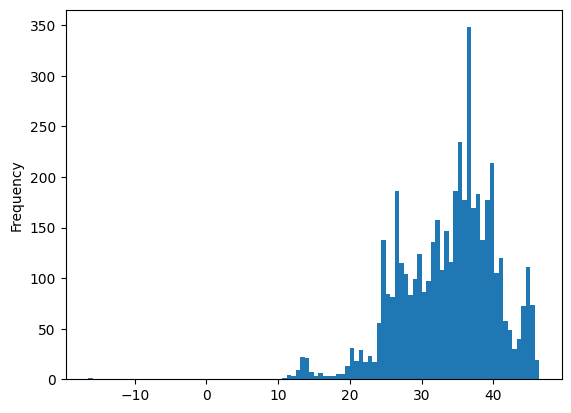

In [41]:
df6['track_temperature'].plot.hist(bins=100)

In [42]:
df6['rainfall'].value_counts(dropna=False)

rainfall
False    4665
Name: count, dtype: int64

In [43]:
df6.columns

Index(['year', 'session_id', 'timestamp', 'timing_from_session', 'rainfall',
       'air_temperature', 'humidity', 'pressure', 'track_temperature',
       'wind_direction', 'wind_speed'],
      dtype='object')

In [44]:
class SessionWeather(BaseModel):
    year: int
    session_id: str
    timestamp: datetime
    timing_from_session: float
    rainfall: bool
    air_temperature: Optional[float]
    humidity: Optional[float]
    pressure: Optional[float]
    track_temperature: Optional[float]
    wind_direction: Optional[float]
    wind_speed: Optional[float]
    
    @staticmethod
    def parse_float(value):
        try:
            if np.isnan(value):
                return None
            if value:
                return float(value)            
        except (TypeError, ValueError):
            return None

    @field_validator('air_temperature', mode='before')
    @staticmethod
    def air_temperature(value):
        return SessionWeather.parse_float(value)

    @field_validator('humidity', mode='before')
    @staticmethod
    def humidity(value):
        return SessionWeather.parse_float(value)

    @field_validator('pressure', mode='before')
    @staticmethod
    def pressure(value):
        return SessionWeather.parse_float(value)

    @field_validator('track_temperature', mode='before')
    @staticmethod
    def track_temperature(value):
        return SessionWeather.parse_float(value)

    @field_validator('wind_direction', mode='before')
    @staticmethod
    def wind_direction(value):
        return SessionWeather.parse_float(value)

    @field_validator('wind_speed', mode='before')
    @staticmethod
    def wind_speed(value):
        return SessionWeather.parse_float(value)



In [45]:
data6 = [SessionWeather(**x) for _, x in df6.iterrows()]

In [46]:
data6[:10]

[SessionWeather(year=2026, session_id='Y2026R01S1', timestamp=Timestamp('2026-03-06 01:15:03.111000+0000', tz='UTC'), timing_from_session=3.099, rainfall=False, air_temperature=20.1, humidity=73.2, pressure=1015.0, track_temperature=33.2, wind_direction=34.0, wind_speed=0.6),
 SessionWeather(year=2026, session_id='Y2026R01S1', timestamp=Timestamp('2026-03-06 01:16:03.114000+0000', tz='UTC'), timing_from_session=63.102, rainfall=False, air_temperature=20.2, humidity=72.9, pressure=1015.1, track_temperature=33.9, wind_direction=15.0, wind_speed=1.2),
 SessionWeather(year=2026, session_id='Y2026R01S1', timestamp=Timestamp('2026-03-06 01:17:03.113000+0000', tz='UTC'), timing_from_session=123.101, rainfall=False, air_temperature=20.2, humidity=72.3, pressure=1015.0, track_temperature=33.3, wind_direction=75.0, wind_speed=1.3),
 SessionWeather(year=2026, session_id='Y2026R01S1', timestamp=Timestamp('2026-03-06 01:18:03.119000+0000', tz='UTC'), timing_from_session=183.107, rainfall=False, air

In [47]:
df7 = pd.read_parquet([x for x in files if get_type(x.name)=='session_race_control_messages'][0])
df7.head().T
    


,0,1,2,3,4
year,2025,2025,2025,2025,2025
session_id,Y2025R01S1,Y2025R01S1,Y2025R01S1,Y2025R01S1,Y2025R01S1
timestamp,2025-03-14 01:30:00+00:00,2025-03-14 01:48:31+00:00,2025-03-14 01:53:58+00:00,2025-03-14 01:54:03+00:00,2025-03-14 01:54:05+00:00
timing_from_session,871.991,1982.991,2309.991,2314.991,2316.991
category,Flag,Flag,Other,Flag,Drs
message,GREEN LIGHT - PIT EXIT OPEN,RED FLAG,SESSION WILL RESUME AT 12:55,TRACK CLEAR,DRS ENABLED
status,None,None,None,None,ENABLED
flag,GREEN,RED,None,CLEAR,None
scope,Track,Track,None,Track,None
sector,<NA>,<NA>,<NA>,<NA>,<NA>


In [48]:
df7['sector'].value_counts(dropna=False)

sector
<NA>    3960
5        186
2        156
11       155
15       144
6        141
14       138
7        126
16       124
10       119
4        115
13       111
8        103
17        99
18        96
3         96
9         94
12        85
20        55
1         53
19        41
21        16
28         3
24         2
27         2
26         2
Name: count, dtype: Int64

In [49]:
class SessionRaceControlMessages(BaseModel):
    year: int
    session_id: str
    timestamp: datetime
    timing_from_session: float
    category: Literal["Flag", "Drs", "SafetyCar", "Other"]
    message: Optional[str]
    status: Literal[None, "ENABLED", "DISABLED", "DEPLOYED", "ENDING", "IN THIS LAP", "THROUGH THE PIT LANE"]
    flag: Literal[None, "CLEAR", "YELLOW", "DOUBLE YELLOW", "BLUE", "GREEN", "CHEQUERED", "RED", "BLACK AND WHITE"]
    scope: Literal[None, "Sector", "Track", "Driver"]
    sector: Optional[int]
    driver_number: Optional[int]
    lap_number: Optional[int]

    @staticmethod
    def parse_int(value):
        try:
            return int(value)
        except (TypeError, ValueError):
            return None

    @field_validator("sector", mode="before")
    @staticmethod
    def sector(value):
        return SessionResults.parse_int(value)

    @field_validator("driver_number", mode="before")
    @staticmethod
    def driver_number(value):
        return SessionResults.parse_int(value)

    @field_validator("lap_number", mode="before")
    @staticmethod
    def lap_number(value):
        return SessionResults.parse_int(value)


In [50]:
data7 = [SessionRaceControlMessages(**x) for _, x in df7.iterrows()]

In [51]:
data7[:10]

[SessionRaceControlMessages(year=2025, session_id='Y2025R01S1', timestamp=Timestamp('2025-03-14 01:30:00+0000', tz='UTC'), timing_from_session=871.991, category='Flag', message='GREEN LIGHT - PIT EXIT OPEN', status=None, flag='GREEN', scope='Track', sector=None, driver_number=None, lap_number=None),
 SessionRaceControlMessages(year=2025, session_id='Y2025R01S1', timestamp=Timestamp('2025-03-14 01:48:31+0000', tz='UTC'), timing_from_session=1982.991, category='Flag', message='RED FLAG', status=None, flag='RED', scope='Track', sector=None, driver_number=None, lap_number=None),
 SessionRaceControlMessages(year=2025, session_id='Y2025R01S1', timestamp=Timestamp('2025-03-14 01:53:58+0000', tz='UTC'), timing_from_session=2309.991, category='Other', message='SESSION WILL RESUME AT 12:55', status=None, flag=None, scope=None, sector=None, driver_number=None, lap_number=None),
 SessionRaceControlMessages(year=2025, session_id='Y2025R01S1', timestamp=Timestamp('2025-03-14 01:54:03+0000', tz='UTC'

In [52]:
df8 = pd.read_parquet([x for x in files if get_type(x.name)=='session_track_status'][0])
df8.head().T
    


,0,1,2,3,4
year,2025,2025,2025,2025,2025
session_id,Y2025R01S1,Y2025R01S1,Y2025R01S1,Y2025R01S1,Y2025R01S1
timestamp,2025-03-14 01:15:28.009000+00:00,2025-03-14 01:16:58.723000+00:00,2025-03-14 01:48:31.184000+00:00,2025-03-14 01:54:03.347000+00:00,2025-03-14 01:58:50.942000+00:00
timing_from_session,0.0,90.714,1983.175,2315.338,2602.933
status,2,1,5,1,2
message,Yellow,AllClear,Red,AllClear,Yellow


In [53]:
df8['message'].value_counts(dropna=False)

message
AllClear       672
Yellow         586
Red             69
SCDeployed      29
VSCDeployed     28
VSCEnding       23
Name: count, dtype: int64

In [54]:
class SessionTrackStatus(BaseModel):
    year: int
    session_id: str
    timestamp: datetime
    timing_from_session: float
    status: Literal[1, 2, 3, 4, 5, 6, 7]
    message: Literal['Yellow', 'AllClear', 'Red', 'SCDeployed', 'VSCDeployed', 'VSCEnding']



In [55]:
data8 = [SessionTrackStatus(**x) for _, x in df8.iterrows()]

In [56]:
data8

[SessionTrackStatus(year=2025, session_id='Y2025R01S1', timestamp=Timestamp('2025-03-14 01:15:28.009000+0000', tz='UTC'), timing_from_session=0.0, status=2, message='Yellow'),
 SessionTrackStatus(year=2025, session_id='Y2025R01S1', timestamp=Timestamp('2025-03-14 01:16:58.723000+0000', tz='UTC'), timing_from_session=90.714, status=1, message='AllClear'),
 SessionTrackStatus(year=2025, session_id='Y2025R01S1', timestamp=Timestamp('2025-03-14 01:48:31.184000+0000', tz='UTC'), timing_from_session=1983.175, status=5, message='Red'),
 SessionTrackStatus(year=2025, session_id='Y2025R01S1', timestamp=Timestamp('2025-03-14 01:54:03.347000+0000', tz='UTC'), timing_from_session=2315.338, status=1, message='AllClear'),
 SessionTrackStatus(year=2025, session_id='Y2025R01S1', timestamp=Timestamp('2025-03-14 01:58:50.942000+0000', tz='UTC'), timing_from_session=2602.933, status=2, message='Yellow'),
 SessionTrackStatus(year=2025, session_id='Y2025R01S1', timestamp=Timestamp('2025-03-14 01:58:54.0660

In [63]:
df9 = pd.read_parquet([x for x in files if get_type(x.name)=='circuit_markers'][0])
df9.head().T

,0,1,2,3,4
year,2025,2025,2025,2025,2025
session_id,Y2025R01S1,Y2025R01S1,Y2025R01S1,Y2025R01S1,Y2025R01S1
annotation_type,corner,corner,corner,corner,corner
number,1,2,3,4,5
letter,None,None,None,None,None
coordinate_x,-3650.594482,-3555.053223,-7194.970215,-5878.734375,-5870.662598
coordinate_y,1193.78418,1992.750244,7101.942383,7709.864746,9676.805664
angle,-176.63273,-1.517007,162.258315,-23.426263,159.215959
distance,345.265369,429.617896,1067.181451,1221.765,1418.713587
rotation,44.0,44.0,44.0,44.0,44.0


In [64]:
df9.isna().sum()

year                  0
session_id            0
annotation_type       0
number                0
letter             6638
coordinate_x          0
coordinate_y          0
angle                 0
distance              0
rotation              0
dtype: int64

In [65]:
df9['annotation_type'].value_counts()

annotation_type
marshal_lights     2294
marshal_sectors    2294
corner             2060
Name: count, dtype: int64

In [66]:
class CircuitMarkers(BaseModel):
    year: int
    session_id: str
    annotation_type: Literal["corner", "marshal_lights", "marshal_sectors"]
    number: int
    letter: Optional[str]
    coordinate_x: float
    coordinate_y: float
    angle: float
    distance: float
    rotation: float


In [67]:
data9 = [CircuitMarkers(**x) for _, x in df9.iterrows()]

In [68]:
data9

[CircuitMarkers(year=2025, session_id='Y2025R01S1', annotation_type='corner', number=1, letter=None, coordinate_x=-3650.594482421875, coordinate_y=1193.7841796875, angle=-176.6327301808908, distance=345.26536875061646, rotation=44.0),
 CircuitMarkers(year=2025, session_id='Y2025R01S1', annotation_type='corner', number=2, letter=None, coordinate_x=-3555.05322265625, coordinate_y=1992.750244140625, angle=-1.517006670514226, distance=429.61789607079515, rotation=44.0),
 CircuitMarkers(year=2025, session_id='Y2025R01S1', annotation_type='corner', number=3, letter=None, coordinate_x=-7194.97021484375, coordinate_y=7101.9423828125, angle=162.2583145895855, distance=1067.1814508018256, rotation=44.0),
 CircuitMarkers(year=2025, session_id='Y2025R01S1', annotation_type='corner', number=4, letter=None, coordinate_x=-5878.734375, coordinate_y=7709.86474609375, angle=-23.426262936440693, distance=1221.7649999870641, rotation=44.0),
 CircuitMarkers(year=2025, session_id='Y2025R01S1', annotation_ty

In [69]:
df10 = pd.read_parquet([x for x in files if get_type(x.name)=='telemetry_car'][0])
df10.head().T

,0,1,2,3,4
year,2025,2025,2025,2025,2025
session_id,Y2025R23S1,Y2025R23S1,Y2025R23S1,Y2025R23S1,Y2025R23S1
driver_number,1,1,1,1,1
lap_number,1,1,1,1,1
timestamp,2025-11-28 13:30:37.774000+00:00,2025-11-28 13:30:38.014000+00:00,2025-11-28 13:30:38.294000+00:00,2025-11-28 13:30:38.534000+00:00,2025-11-28 13:30:38.854000+00:00
timing_from_session,654.271,654.511,654.791,655.031,655.351
timing_from_lap,0.147,0.387,0.667,0.907,1.227
track_status,<NA>,<NA>,<NA>,<NA>,<NA>
rpm,2857.0,3047.0,2802.0,2891.0,3378.0
speed,13.0,13.0,19.0,23.0,28.0


In [70]:
df10.isna().sum()

year                       0
session_id                 0
driver_number              0
lap_number                 0
timestamp                  0
timing_from_session        0
timing_from_lap            0
track_status           13218
rpm                        0
speed                      0
ngear                      0
throttle                   0
brake                      0
drs                        0
dtype: int64

In [71]:
df10['ngear'].value_counts()

ngear
4.0     197343
7.0     185174
5.0     173454
6.0     172633
0.0     159158
3.0      94241
8.0      52404
2.0      47841
1.0      30957
15.0         2
30.0         2
12.0         1
14.0         1
25.0         1
17.0         1
19.0         1
22.0         1
18.0         1
26.0         1
27.0         1
23.0         1
21.0         1
13.0         1
11.0         1
10.0         1
Name: count, dtype: int64

In [72]:
class TelemetryCar(BaseModel):
    year: int
    session_id: str
    driver_number: int
    lap_number: int
    timestamp: datetime
    timing_from_session: float
    timing_from_lap: float
    track_status: Optional[int]
    rpm: float
    speed: float
    ngear: int
    speed: float
    brake: float
    drs: int

    @staticmethod
    def parse_int(value):
        try:
            return int(value)
        except (TypeError, ValueError):
            return None

    @field_validator('track_status', mode='before')
    @staticmethod
    def track_status(value):
        return SessionLaps.parse_int(value)


In [73]:
data10 = [TelemetryCar(**x) for _, x in df10.iterrows()]

In [74]:
data10[:5]

[TelemetryCar(year=2025, session_id='Y2025R23S1', driver_number=1, lap_number=1, timestamp=Timestamp('2025-11-28 13:30:37.774000+0000', tz='UTC'), timing_from_session=654.271, timing_from_lap=0.147, track_status=None, rpm=2857.0, speed=13.0, ngear=1, brake=0.0, drs=8),
 TelemetryCar(year=2025, session_id='Y2025R23S1', driver_number=1, lap_number=1, timestamp=Timestamp('2025-11-28 13:30:38.014000+0000', tz='UTC'), timing_from_session=654.511, timing_from_lap=0.387, track_status=None, rpm=3047.0, speed=13.0, ngear=1, brake=0.0, drs=8),
 TelemetryCar(year=2025, session_id='Y2025R23S1', driver_number=1, lap_number=1, timestamp=Timestamp('2025-11-28 13:30:38.294000+0000', tz='UTC'), timing_from_session=654.791, timing_from_lap=0.667, track_status=None, rpm=2802.0, speed=19.0, ngear=1, brake=0.0, drs=8),
 TelemetryCar(year=2025, session_id='Y2025R23S1', driver_number=1, lap_number=1, timestamp=Timestamp('2025-11-28 13:30:38.534000+0000', tz='UTC'), timing_from_session=655.031, timing_from_la

In [75]:
df11 = pd.read_parquet([x for x in files if get_type(x.name)=='telemetry_pos'][0])
df11.head().T

,0,1,2,3,4
year,2025,2025,2025,2025,2025
session_id,Y2025R16S1,Y2025R16S1,Y2025R16S1,Y2025R16S1,Y2025R16S1
driver_number,1,1,1,1,1
lap_number,1,1,1,1,1
timestamp,2025-09-05 11:30:58.623000+00:00,2025-09-05 11:30:58.763000+00:00,2025-09-05 11:30:59.103000+00:00,2025-09-05 11:30:59.503000+00:00,2025-09-05 11:30:59.883000+00:00
timing_from_session,882.729,882.869,883.209,883.609,883.989
timing_from_lap,0.219,0.359,0.699,1.099,1.479
track_status,1,1,1,1,1
coordinate_x,-925.0,-925.0,-925.0,-925.0,-925.0
coordinate_y,2310.0,2310.0,2310.0,2310.0,2310.0


In [76]:
class TelemetryPos(BaseModel):
    year: int
    session_id: str
    driver_number: int
    lap_number: int
    timestamp: datetime
    timing_from_session: float
    timing_from_lap: float
    track_status: Optional[int]
    coordinate_x: float
    coordinate_y: float
    coordinate_z: float
    position_status: Literal["OnTrack", "OffTrack"]

    @staticmethod
    def parse_int(value):
        try:
            return int(value)
        except (TypeError, ValueError):
            return None

    @field_validator('track_status', mode='before')
    @staticmethod
    def track_status(value):
        return SessionLaps.parse_int(value)


In [77]:
data11 = [TelemetryPos(**x) for _, x in df11.iterrows()]

In [78]:
data11[:50]

[TelemetryPos(year=2025, session_id='Y2025R16S1', driver_number=1, lap_number=1, timestamp=Timestamp('2025-09-05 11:30:58.623000+0000', tz='UTC'), timing_from_session=882.729, timing_from_lap=0.219, track_status=1, coordinate_x=-925.0, coordinate_y=2310.0, coordinate_z=0.0, position_status='OnTrack'),
 TelemetryPos(year=2025, session_id='Y2025R16S1', driver_number=1, lap_number=1, timestamp=Timestamp('2025-09-05 11:30:58.763000+0000', tz='UTC'), timing_from_session=882.869, timing_from_lap=0.359, track_status=1, coordinate_x=-925.0, coordinate_y=2310.0, coordinate_z=0.0, position_status='OnTrack'),
 TelemetryPos(year=2025, session_id='Y2025R16S1', driver_number=1, lap_number=1, timestamp=Timestamp('2025-09-05 11:30:59.103000+0000', tz='UTC'), timing_from_session=883.209, timing_from_lap=0.699, track_status=1, coordinate_x=-925.0, coordinate_y=2310.0, coordinate_z=0.0, position_status='OnTrack'),
 TelemetryPos(year=2025, session_id='Y2025R16S1', driver_number=1, lap_number=1, timestamp=

In [79]:
df2

,year,session_id,session_name,f1_api_support,timestamp_reference,timing_start,session_scheduled_time,total_laps,driver_list,meeting_key,...,round_number,event_country,event_location,event_name,event_official_name,event_date,event_format,type,scheduled_time_utc,scheduled_time_local
0,2026,Y2026R01S1,Practice 1,True,2026-03-06 01:15:00.012000+00:00,900.171,2026-03-06 01:30:00+00:00,NaN,"[1, 3, 5, 6, 10, 11, 12, 14, 16, 18, 23, 27, 3...",1279,...,1,Australia,Melbourne,Australian Grand Prix,FORMULA 1 QATAR AIRWAYS AUSTRALIAN GRAND PRIX ...,2026-03-08,conventional,Practice 1,2026-03-06 01:30:00+00:00,2026-03-06T12:30:00+11:00
1,2026,Y2026R01S2,Practice 2,True,2026-03-06 04:47:12.180000+00:00,767.995,2026-03-06 05:00:00+00:00,NaN,"[1, 3, 5, 6, 10, 11, 12, 14, 16, 18, 23, 27, 3...",1279,...,1,Australia,Melbourne,Australian Grand Prix,FORMULA 1 QATAR AIRWAYS AUSTRALIAN GRAND PRIX ...,2026-03-08,conventional,Practice 2,2026-03-06 05:00:00+00:00,2026-03-06T16:00:00+11:00
2,2026,Y2026R01S3,Practice 3,True,2026-03-07 01:24:00.062000+00:00,1560.124,2026-03-07 01:30:00+00:00,NaN,"[1, 3, 5, 6, 10, 11, 12, 14, 16, 18, 23, 27, 3...",1279,...,1,Australia,Melbourne,Australian Grand Prix,FORMULA 1 QATAR AIRWAYS AUSTRALIAN GRAND PRIX ...,2026-03-08,conventional,Practice 3,2026-03-07 01:30:00+00:00,2026-03-07T12:30:00+11:00
3,2026,Y2026R01S4,Qualifying,True,2026-03-07 04:47:18.712000+00:00,761.484,2026-03-07 05:00:00+00:00,NaN,"[1, 3, 5, 6, 10, 11, 12, 14, 16, 18, 23, 27, 3...",1279,...,1,Australia,Melbourne,Australian Grand Prix,FORMULA 1 QATAR AIRWAYS AUSTRALIAN GRAND PRIX ...,2026-03-08,conventional,Qualifying,2026-03-07 05:00:00+00:00,2026-03-07T16:00:00+11:00
4,2026,Y2026R01S5,Race,True,2026-03-08 03:01:06.623000+00:00,3739.743,2026-03-08 04:00:00+00:00,58.0,"[1, 3, 5, 6, 10, 11, 12, 14, 16, 18, 23, 27, 3...",1279,...,1,Australia,Melbourne,Australian Grand Prix,FORMULA 1 QATAR AIRWAYS AUSTRALIAN GRAND PRIX ...,2026-03-08,conventional,Race,2026-03-08 04:00:00+00:00,2026-03-08T15:00:00+11:00
5,2026,Y2026R02S1,Practice 1,True,2026-03-13 03:15:55.193000+00:00,845.036,2026-03-13 03:30:00+00:00,NaN,"[1, 3, 5, 6, 10, 11, 12, 14, 16, 18, 23, 27, 3...",1280,...,2,China,Shanghai,Chinese Grand Prix,FORMULA 1 HEINEKEN CHINESE GRAND PRIX 2026,2026-03-15,sprint_qualifying,Practice 1,2026-03-13 03:30:00+00:00,2026-03-13T11:30:00+08:00
6,2026,Y2026R02S2,Sprint Qualifying,True,2026-03-13 07:17:19.131000+00:00,761.102,2026-03-13 07:30:00+00:00,NaN,"[1, 3, 5, 6, 10, 11, 12, 14, 16, 18, 23, 27, 3...",1280,...,2,China,Shanghai,Chinese Grand Prix,FORMULA 1 HEINEKEN CHINESE GRAND PRIX 2026,2026-03-15,sprint_qualifying,Sprint Qualifying,2026-03-13 07:30:00+00:00,2026-03-13T15:30:00+08:00
7,2026,Y2026R02S3,Sprint,True,2026-03-14 02:17:12.374000+00:00,2801.459,2026-03-14 03:00:00+00:00,19.0,"[1, 3, 5, 6, 10, 11, 12, 14, 16, 18, 23, 27, 3...",1280,...,2,China,Shanghai,Chinese Grand Prix,FORMULA 1 HEINEKEN CHINESE GRAND PRIX 2026,2026-03-15,sprint_qualifying,Sprint,2026-03-14 03:00:00+00:00,2026-03-14T11:00:00+08:00
8,2026,Y2026R02S4,Qualifying,True,2026-03-14 06:45:09.312000+00:00,890.898,2026-03-14 07:00:00+00:00,NaN,"[1, 3, 5, 6, 10, 11, 12, 14, 16, 18, 23, 27, 3...",1280,...,2,China,Shanghai,Chinese Grand Prix,FORMULA 1 HEINEKEN CHINESE GRAND PRIX 2026,2026-03-15,sprint_qualifying,Qualifying,2026-03-14 07:00:00+00:00,2026-03-14T15:00:00+08:00
9,2026,Y2026R02S5,Race,True,2026-03-15 06:07:35.781000+00:00,3384.050,2026-03-15 07:00:00+00:00,56.0,"[1, 3, 5, 6, 10, 11, 12, 14, 16, 18, 23, 27, 3...",1280,...,2,China,Shanghai,Chinese Grand Prix,FORMULA 1 HEINEKEN CHINESE GRAND PRIX 2026,2026-03-15,sprint_qualifying,Race,2026-03-15 07:00:00+00:00,2026-03-15T15:00:00+08:00


In [80]:
idx = ['session_id', 'driver_number']
print(df3[idx].isna().sum())
print(df3[idx].value_counts().value_counts())


session_id       0
driver_number    0
dtype: int64
count
1    2454
Name: count, dtype: int64


In [81]:
df1[idx].value_counts()

KeyError: "None of [Index(['session_id', 'driver_number'], dtype='object')] are in the [columns]"

In [ ]:
df1[(df1['year']==2026)&(df1['round_number']==0)]

In [ ]:
idx = ['year', 'official_event_name', 'session_number']
print(df1[idx].isna().sum())
print(df1[idx].value_counts().value_counts())
